In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
from datetime import datetime
import os
style.use('fast')
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score  
from statistics import mean

def ROC_PR_AUC_Curves(Values_real,Value_infered, number_genes, file_path_data, algorithm, color_ROC="indigo", color_PR= "springgreen", show_plot=False):
    """
        This functions returns the area under the ROC and PR curve 
        and plots the tpr vs fpr and the precision vs recall.
    """
    
    #ROC
    fpr, tpr, thresholds = roc_curve(Values_real, Value_infered)
    AUC_ROC = auc(fpr, tpr)
    
    
    #PR
    precision, recall, thresholds = precision_recall_curve(Values_real, Value_infered)
    AUC_PR = auc(recall, precision)
    
    if show_plot==True:
        
        plt.rc('xtick', labelsize=22)    
        plt.rc('ytick', labelsize=22)    
        plt.rcParams["font.family"] = "serif"
    
        plt.figure(figsize=(9,7))
        plt.plot([0, 1], [0, 1], 'k--',  lw=2.8)
        plt.plot(fpr, tpr, lw=2.8, color=color_ROC,label='Area = {:.3f}'.format(AUC_ROC))
        plt.fill_between(fpr, tpr,color=color_ROC, alpha=0.28)
        plt.xlabel('False positive rate',family="serif",fontsize = 26)
        plt.ylabel('True positive rate',family="serif",fontsize = 26)
        plt.title(f'ROC {number_genes} Genes, {algorithm}',family="serif",fontsize = 31)
        plt.legend(prop={'size':20, 'family':'serif'},loc='lower right')
        #plt.savefig(f"{file_path_data}/ROC_curve_Genes-{number_genes}.png", bbox_inches="tight", dpi=100 )
        
        plt.figure(figsize=(9,7))
        plt.plot([0, 1], [1, 0], 'k--',  lw=2.8)
        plt.plot(recall, precision, lw=2.8, color=color_PR,label='Area = {:.3f}'.format(AUC_PR))
        plt.fill_between(recall, precision,color=color_PR, alpha=0.28)
        plt.xlabel('Recall',family="serif",fontsize = 26)
        plt.ylabel('Precision',family="serif",fontsize = 26)
        plt.title(f'PRC {number_genes} Genes, {algorithm}',family="serif",fontsize = 31)
        plt.legend(prop={'size':20, 'family':'serif'},loc='lower right')
        #plt.savefig(f"{file_path_data}/PR_curve_Genes-{number_genes}.png", bbox_inches="tight", dpi=100 )
        
    
    return AUC_ROC, AUC_PR


In [8]:
file_path_results = "Computing_Performance_3_in_degree/"
try:
    os.mkdir(file_path_results)
except OSError as error:
    print(f"Folder {file_path_results} already created.")
    
header_list_dynGENIE3_rand = ["Cause Gene", "Effect Gene", "mean_importance"]
header_list = ["Cause Gene", "Effect Gene", "Value"]
gold_standard = {}
Nodes = [10, 20, 50, 100]
step = 10

AUROC_value_dynGENIE3_list = {}
AUPRC_value_dynGENIE3_list = {}

AUROC_value_SWING_list = {}
AUPRC_value_SWING_list = {}

AUROC_value_dynGENIE3_list_rand = {}
AUPRC_value_dynGENIE3_list_rand = {}

AUROC_value_dynGENIE3_list_crand = {}
AUPRC_value_dynGENIE3_list_crand = {}

AUROC_value_SWING_list_rand = {}
AUPRC_value_SWING_list_rand = {}

AUROC_value_SWING_list_crand = {}
AUPRC_value_SWING_list_crand = {}

AUROC_value_random_list = {}
AUPRC_value_random_list = {}

for nodes in Nodes:
    
    AUROC_value_dynGENIE3_list[f"AUROC_value_dynGENIE3_list_{nodes}genes"] = []
    AUPRC_value_dynGENIE3_list[f"AUPRC_value_dynGENIE3_list_{nodes}genes"] = []
    
    AUROC_value_SWING_list[f"AUROC_value_SWING_list_{nodes}genes"] = []
    AUPRC_value_SWING_list[f"AUPRC_value_SWING_list_{nodes}genes"] = []
    
    AUROC_value_dynGENIE3_list_rand[f"AUROC_value_dynGENIE3_list_{nodes}genes_rand"] = []
    AUPRC_value_dynGENIE3_list_rand[f"AUPRC_value_dynGENIE3_list_{nodes}genes_rand"] = []
    
    AUROC_value_SWING_list_rand[f"AUROC_value_SWING_list_{nodes}genes_rand"] = []
    AUPRC_value_SWING_list_rand[f"AUPRC_value_SWING_list_{nodes}genes_rand"] = []
    
    AUROC_value_dynGENIE3_list_crand[f"AUROC_value_dynGENIE3_list_{nodes}genes_crand"] = []
    AUPRC_value_dynGENIE3_list_crand[f"AUPRC_value_dynGENIE3_list_{nodes}genes_crand"] = []
    
    AUROC_value_SWING_list_crand[f"AUROC_value_SWING_list_{nodes}genes_crand"] = []
    AUPRC_value_SWING_list_crand[f"AUPRC_value_SWING_list_{nodes}genes_crand"] = []
    
    AUROC_value_random_list[f"AUROC_value_random_list_{nodes}genes"] = []
    AUPRC_value_random_list[f"AUPRC_value_random_list_{nodes}genes"] = []
    
    for instance in range(100):
        
        instance = instance + 1
        
        mean_importance_file_SWING = pd.read_csv(f"networks_in_out_degree_3_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_SWING_{instance}.tsv", sep ="\t")
        mean_importance_file_dynGENIE3= pd.read_csv(f"networks_in_out_degree_3_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_dynGENIE3_{instance}", sep ="\t").sort_values(by=["Cause Gene", "Effect Gene"])
        
        mean_importance_file_SWING_rand = pd.read_csv(f"networks_in_out_degree_3_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_rand/mean_importance_SWING_{instance}_rand.tsv", sep ="\t")
        mean_importance_file_dynGENIE3_rand = pd.read_csv(f"networks_in_out_degree_3_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_rand/mean_importance_dynGENIE3_{instance}_rand.tsv", sep ="\t", names = header_list_dynGENIE3_rand).sort_values(by=["Cause Gene", "Effect Gene"])
        
        mean_importance_file_SWING_crand = pd.read_csv(f"networks_in_out_degree_3_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_crand/mean_importance_SWING_{instance}_crand.tsv", sep ="\t")
        mean_importance_file_dynGENIE3_crand = pd.read_csv(f"networks_in_out_degree_3_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_crand/mean_importance_dynGENIE3_{instance}_crand.tsv", sep ="\t", names = header_list_dynGENIE3_rand).sort_values(by=["Cause Gene", "Effect Gene"])
    
        rank_SWING = mean_importance_file_SWING["mean_importance"]
        rank_dynGENIE3 = mean_importance_file_dynGENIE3["mean_importance"]
        
        rank_SWING_rand = mean_importance_file_SWING_rand["mean_importance"]
        rank_dynGENIE3_rand = mean_importance_file_dynGENIE3_rand["mean_importance"]
        
        rank_SWING_crand = mean_importance_file_SWING_crand["mean_importance"]
        rank_dynGENIE3_crand = mean_importance_file_dynGENIE3_crand["mean_importance"]
        
        if nodes == 10:                                                                                                                                   
            gold_standard = pd.read_csv(f"networks_in_out_degree_3_num_nodes_{nodes}/Networks_in_out_degree_3_num_nodes_{nodes}/in_and_out_degree_2_num_nodes_{nodes}_case_{instance}/goldstandard_signed_{instance}_goldstandard.tsv", sep="\t", names= header_list)
            gold_standard = gold_standard.sort_values(by=["Cause Gene", "Effect Gene"])
        else:
            gold_standard = pd.read_csv(f"networks_in_out_degree_3_num_nodes_{nodes}/Networks_in_out_degree_3_num_nodes_{nodes}/in_and_out_degree_3_num_nodes_{nodes}_case_{instance}/goldstandard_signed_{instance}_goldstandard.tsv", sep="\t", names= header_list)
            gold_standard = gold_standard.sort_values(by=["Cause Gene", "Effect Gene"])
        
        AUROC_value_dynGENIE3, AUPRC_value_dynGENIE3 = ROC_PR_AUC_Curves(gold_standard["Value"], rank_dynGENIE3, nodes, "Nothing", f"dynGENIE3 Run {instance}", show_plot=False)
        AUROC_value_SWING, AUPRC_value_SWING = ROC_PR_AUC_Curves(gold_standard["Value"], rank_SWING , nodes, "Nothing", f"SWING Run {instance}", show_plot=False)
        
        AUROC_value_dynGENIE3_rand, AUPRC_value_dynGENIE3_rand = ROC_PR_AUC_Curves(gold_standard["Value"], rank_dynGENIE3_rand, nodes, "Nothing", f"dynGENIE3 Run {instance}", show_plot=False)
        AUROC_value_SWING_rand, AUPRC_value_SWING_rand = ROC_PR_AUC_Curves(gold_standard["Value"], rank_SWING_rand , nodes, "Nothing", f"SWING Run {instance}", show_plot=False)
        
        AUROC_value_dynGENIE3_crand, AUPRC_value_dynGENIE3_crand = ROC_PR_AUC_Curves(gold_standard["Value"], rank_dynGENIE3_crand, nodes, "Nothing", f"dynGENIE3 Run {instance}", show_plot=False)
        AUROC_value_SWING_crand, AUPRC_value_SWING_crand = ROC_PR_AUC_Curves(gold_standard["Value"], rank_SWING_crand , nodes, "Nothing", f"SWING Run {instance}", show_plot=False)
        
        AUROC_value_random, AUPRC_value_random = ROC_PR_AUC_Curves(gold_standard["Value"], np.random.rand(1,len(rank_SWING))[0].tolist() , nodes, "Nothing", f"Random Run {instance}", show_plot=False)
        
        print(f"AUROC SWING value Run {instance}: ", AUROC_value_SWING)
        print(f"AUPRC SWING value Run {instance}: ", AUPRC_value_SWING)
        
        print(f"AUROC dynGENIE3 value Run {instance}: ", AUROC_value_dynGENIE3)
        print(f"AUPRC dynGENIE3 value Run {instance}: ", AUPRC_value_dynGENIE3)
        
        print(f"AUROC SWING rand value Run {instance}: ", AUROC_value_SWING_rand)
        print(f"AUPRC SWING rand value Run {instance}: ", AUPRC_value_SWING_rand)
        
        print(f"AUROC dynGENIE3 rand value Run {instance}: ", AUROC_value_dynGENIE3_rand)
        print(f"AUPRC dynGENIE3 rand value Run {instance}: ", AUPRC_value_dynGENIE3_rand)
        
        print(f"AUROC SWING crand value Run {instance}: ", AUROC_value_SWING_crand)
        print(f"AUPRC SWING crand value Run {instance}: ", AUPRC_value_SWING_crand)
        
        print(f"AUROC dynGENIE3 crand value Run {instance}: ", AUROC_value_dynGENIE3_crand)
        print(f"AUPRC dynGENIE3 crand value Run {instance}: ", AUPRC_value_dynGENIE3_crand)
        
        print(f"AUROC random value Run {instance}: ", AUROC_value_random)
        print(f"AUPRC random value Run {instance}: ", AUROC_value_random)
        
        AUROC_value_SWING_list[f"AUROC_value_SWING_list_{nodes}genes"].append(AUROC_value_SWING)
        AUPRC_value_SWING_list[f"AUPRC_value_SWING_list_{nodes}genes"].append(AUPRC_value_SWING)
        
        AUROC_value_dynGENIE3_list[f"AUROC_value_dynGENIE3_list_{nodes}genes"].append(AUROC_value_dynGENIE3)
        AUPRC_value_dynGENIE3_list[f"AUPRC_value_dynGENIE3_list_{nodes}genes"].append(AUPRC_value_dynGENIE3)
        
        AUROC_value_SWING_list_rand[f"AUROC_value_SWING_list_{nodes}genes_rand"].append(AUROC_value_SWING_rand)
        AUPRC_value_SWING_list_rand[f"AUPRC_value_SWING_list_{nodes}genes_rand"].append(AUPRC_value_SWING_rand)
        
        AUROC_value_dynGENIE3_list_rand[f"AUROC_value_dynGENIE3_list_{nodes}genes_rand"].append(AUROC_value_dynGENIE3_rand)
        AUPRC_value_dynGENIE3_list_rand[f"AUPRC_value_dynGENIE3_list_{nodes}genes_rand"].append(AUPRC_value_dynGENIE3_rand)
        
        
        AUROC_value_SWING_list_crand[f"AUROC_value_SWING_list_{nodes}genes_crand"].append(AUROC_value_SWING_crand)
        AUPRC_value_SWING_list_crand[f"AUPRC_value_SWING_list_{nodes}genes_crand"].append(AUPRC_value_SWING_crand)
        
        AUROC_value_dynGENIE3_list_crand[f"AUROC_value_dynGENIE3_list_{nodes}genes_crand"].append(AUROC_value_dynGENIE3_crand)
        AUPRC_value_dynGENIE3_list_crand[f"AUPRC_value_dynGENIE3_list_{nodes}genes_crand"].append(AUPRC_value_dynGENIE3_crand)
        
        
        AUROC_value_random_list[f"AUROC_value_random_list_{nodes}genes"].append(AUROC_value_random)
        AUPRC_value_random_list[f"AUPRC_value_random_list_{nodes}genes"].append(AUPRC_value_random)
    
    AUROC_file_SWING = open(f"{file_path_results}/AUROC_results_{nodes}genes_SWING.txt", "w")
    AUROC_file_dynGENIE3 = open(f"{file_path_results}/AUROC_results_{nodes}genes_dynGENIE3.txt", "w")
    AUROC_file_SWING_rand = open(f"{file_path_results}/AUROC_results_{nodes}genes_SWING_rand.txt", "w")
    AUROC_file_dynGENIE3_rand = open(f"{file_path_results}/AUROC_results_{nodes}genes_dynGENIE3_rand.txt", "w")
    AUROC_file_SWING_crand = open(f"{file_path_results}/AUROC_results_{nodes}genes_SWING_crand.txt", "w")
    AUROC_file_dynGENIE3_crand = open(f"{file_path_results}/AUROC_results_{nodes}genes_dynGENIE3_crand.txt", "w")
    AUROC_file_random = open(f"{file_path_results}/AUROC_results_{nodes}genes_random.txt", "w")
    
    AUPRC_file_SWING = open(f"{file_path_results}/AUPRC_results_{nodes}genes_SWING.txt", "w")
    AUPRC_file_dynGENIE3 = open(f"{file_path_results}/AUPRC_results_{nodes}genes_dynGENIE3.txt", "w")
    AUPRC_file_SWING_rand = open(f"{file_path_results}/AUPRC_results_{nodes}genes_SWING_rand.txt", "w")
    AUPRC_file_dynGENIE3_rand = open(f"{file_path_results}/AUPRC_results_{nodes}genes_dynGENIE3_rand.txt", "w")
    AUPRC_file_SWING_crand = open(f"{file_path_results}/AUPRC_results_{nodes}genes_SWING_crand.txt", "w")
    AUPRC_file_dynGENIE3_crand = open(f"{file_path_results}/AUPRC_results_{nodes}genes_dynGENIE3_crand.txt", "w")
    AUPRC_file_random = open(f"{file_path_results}/AUPRC_results_{nodes}genes_random.txt", "w")
    
    for element in AUROC_value_SWING_list[f"AUROC_value_SWING_list_{nodes}genes"]:
        AUROC_file_SWING.write(str(element) + "\n")
    AUROC_file_SWING.close()
    
    for element in AUROC_value_dynGENIE3_list[f"AUROC_value_dynGENIE3_list_{nodes}genes"]:
        AUROC_file_dynGENIE3.write(str(element) + "\n")
    AUROC_file_dynGENIE3.close()
    
    for element in AUROC_value_SWING_list_rand[f"AUROC_value_SWING_list_{nodes}genes_rand"]:
        AUROC_file_SWING_rand.write(str(element) + "\n")
    AUROC_file_SWING_rand.close()
    
    for element in AUROC_value_SWING_list_crand[f"AUROC_value_SWING_list_{nodes}genes_crand"]:
        AUROC_file_SWING_crand.write(str(element) + "\n")
    AUROC_file_SWING_crand.close()
    
    for element in AUROC_value_dynGENIE3_list_rand[f"AUROC_value_dynGENIE3_list_{nodes}genes_rand"]:
        AUROC_file_dynGENIE3_rand.write(str(element) + "\n")
    AUROC_file_dynGENIE3_rand.close()
    
    for element in AUROC_value_dynGENIE3_list_crand[f"AUROC_value_dynGENIE3_list_{nodes}genes_crand"]:
        AUROC_file_dynGENIE3_crand.write(str(element) + "\n")
    AUROC_file_dynGENIE3_crand.close()
    
    for element in AUROC_value_random_list[f"AUROC_value_random_list_{nodes}genes"]:
        AUROC_file_random.write(str(element) + "\n")
    AUROC_file_random.close()
    
    for element in AUPRC_value_SWING_list[f"AUPRC_value_SWING_list_{nodes}genes"]:
        AUPRC_file_SWING.write(str(element) + "\n")
    AUPRC_file_SWING.close()
    
    for element in AUPRC_value_dynGENIE3_list[f"AUPRC_value_dynGENIE3_list_{nodes}genes"]:
        AUPRC_file_dynGENIE3.write(str(element) + "\n")
    AUPRC_file_dynGENIE3.close()
    
    for element in AUPRC_value_SWING_list_rand[f"AUPRC_value_SWING_list_{nodes}genes_rand"]:
        AUPRC_file_SWING_rand.write(str(element) + "\n")
    AUPRC_file_SWING_rand.close()
    
    for element in AUPRC_value_SWING_list_crand[f"AUPRC_value_SWING_list_{nodes}genes_crand"]:
        AUPRC_file_SWING_crand.write(str(element) + "\n")
    AUPRC_file_SWING_crand.close()
    
    for element in AUPRC_value_dynGENIE3_list_rand[f"AUPRC_value_dynGENIE3_list_{nodes}genes_rand"]:
        AUPRC_file_dynGENIE3_rand.write(str(element) + "\n")
    AUPRC_file_dynGENIE3_rand.close()
    
    for element in AUPRC_value_dynGENIE3_list_crand[f"AUPRC_value_dynGENIE3_list_{nodes}genes_crand"]:
        AUPRC_file_dynGENIE3_crand.write(str(element) + "\n")
    AUPRC_file_dynGENIE3_crand.close()
    
    for element in AUPRC_value_random_list[f"AUPRC_value_random_list_{nodes}genes"]:
        AUPRC_file_random.write(str(element) + "\n")
    AUPRC_file_random.close()

Folder Computing_Performance_3_in_degree/ already created.
AUROC SWING value Run 1:  0.7083333333333331
AUPRC SWING value Run 1:  0.5196405831022577
AUROC dynGENIE3 value Run 1:  0.6561111111111112
AUPRC dynGENIE3 value Run 1:  0.458220262079801
AUROC SWING rand value Run 1:  0.625
AUPRC SWING rand value Run 1:  0.42668423715290754
AUROC dynGENIE3 rand value Run 1:  0.49888888888888894
AUPRC dynGENIE3 rand value Run 1:  0.3431934690699758
AUROC SWING crand value Run 1:  0.6361111111111111
AUPRC SWING crand value Run 1:  0.43199073260055854
AUROC dynGENIE3 crand value Run 1:  0.5969444444444445
AUPRC dynGENIE3 crand value Run 1:  0.40286757612842683
AUROC random value Run 1:  0.5711111111111111
AUPRC random value Run 1:  0.5711111111111111
AUROC SWING value Run 2:  0.6838888888888889
AUPRC SWING value Run 2:  0.4638665974657026
AUROC dynGENIE3 value Run 2:  0.5527777777777778
AUPRC dynGENIE3 value Run 2:  0.3638408205374395
AUROC SWING rand value Run 2:  0.5344444444444445
AUPRC SWING r

AUROC SWING value Run 14:  0.655
AUPRC SWING value Run 14:  0.5765253737287744
AUROC dynGENIE3 value Run 14:  0.6494444444444445
AUPRC dynGENIE3 value Run 14:  0.49267143214734044
AUROC SWING rand value Run 14:  0.6083333333333334
AUPRC SWING rand value Run 14:  0.4234068211206421
AUROC dynGENIE3 rand value Run 14:  0.5866666666666668
AUPRC dynGENIE3 rand value Run 14:  0.3887914089143889
AUROC SWING crand value Run 14:  0.5994444444444444
AUPRC SWING crand value Run 14:  0.49728136091218655
AUROC dynGENIE3 crand value Run 14:  0.5994444444444444
AUPRC dynGENIE3 crand value Run 14:  0.3712997950996778
AUROC random value Run 14:  0.5294444444444444
AUPRC random value Run 14:  0.5294444444444444
AUROC SWING value Run 15:  0.5655555555555556
AUPRC SWING value Run 15:  0.44732574142276704
AUROC dynGENIE3 value Run 15:  0.5377777777777778
AUPRC dynGENIE3 value Run 15:  0.38973880311064585
AUROC SWING rand value Run 15:  0.49722222222222223
AUPRC SWING rand value Run 15:  0.35074214898368067

AUROC SWING value Run 26:  0.6416666666666666
AUPRC SWING value Run 26:  0.57425098916837
AUROC dynGENIE3 value Run 26:  0.6411111111111111
AUPRC dynGENIE3 value Run 26:  0.4488017487308221
AUROC SWING rand value Run 26:  0.595
AUPRC SWING rand value Run 26:  0.4824347973243319
AUROC dynGENIE3 rand value Run 26:  0.5738888888888889
AUPRC dynGENIE3 rand value Run 26:  0.4320846742715562
AUROC SWING crand value Run 26:  0.5705555555555556
AUPRC SWING crand value Run 26:  0.4666835495101906
AUROC dynGENIE3 crand value Run 26:  0.6383333333333334
AUPRC dynGENIE3 crand value Run 26:  0.4544779769054544
AUROC random value Run 26:  0.5666666666666667
AUPRC random value Run 26:  0.5666666666666667
AUROC SWING value Run 27:  0.6716666666666667
AUPRC SWING value Run 27:  0.5876216694157635
AUROC dynGENIE3 value Run 27:  0.6405555555555557
AUPRC dynGENIE3 value Run 27:  0.5041762890124155
AUROC SWING rand value Run 27:  0.6338888888888887
AUPRC SWING rand value Run 27:  0.5313749585505572
AUROC d

AUROC SWING value Run 40:  0.7005555555555556
AUPRC SWING value Run 40:  0.583519558465753
AUROC dynGENIE3 value Run 40:  0.6927777777777778
AUPRC dynGENIE3 value Run 40:  0.5627956469901003
AUROC SWING rand value Run 40:  0.6572222222222223
AUPRC SWING rand value Run 40:  0.4818377604104437
AUROC dynGENIE3 rand value Run 40:  0.5866666666666667
AUPRC dynGENIE3 rand value Run 40:  0.4067360582924664
AUROC SWING crand value Run 40:  0.5861111111111111
AUPRC SWING crand value Run 40:  0.5262607637801077
AUROC dynGENIE3 crand value Run 40:  0.6105555555555555
AUPRC dynGENIE3 crand value Run 40:  0.49635729663357825
AUROC random value Run 40:  0.5022222222222222
AUPRC random value Run 40:  0.5022222222222222
AUROC SWING value Run 41:  0.7455555555555556
AUPRC SWING value Run 41:  0.5230208474473481
AUROC dynGENIE3 value Run 41:  0.6072222222222222
AUPRC dynGENIE3 value Run 41:  0.4687985246402531
AUROC SWING rand value Run 41:  0.7316666666666667
AUPRC SWING rand value Run 41:  0.583713301

AUROC SWING value Run 53:  0.5772222222222222
AUPRC SWING value Run 53:  0.39991170966232714
AUROC dynGENIE3 value Run 53:  0.6327777777777779
AUPRC dynGENIE3 value Run 53:  0.5483038564138483
AUROC SWING rand value Run 53:  0.5466666666666666
AUPRC SWING rand value Run 53:  0.36127279509301435
AUROC dynGENIE3 rand value Run 53:  0.4572222222222222
AUPRC dynGENIE3 rand value Run 53:  0.3300407688174847
AUROC SWING crand value Run 53:  0.5155555555555555
AUPRC SWING crand value Run 53:  0.340154847871058
AUROC dynGENIE3 crand value Run 53:  0.5372222222222222
AUPRC dynGENIE3 crand value Run 53:  0.371540030908377
AUROC random value Run 53:  0.5611111111111111
AUPRC random value Run 53:  0.5611111111111111
AUROC SWING value Run 54:  0.6188888888888889
AUPRC SWING value Run 54:  0.4685429486461822
AUROC dynGENIE3 value Run 54:  0.5438888888888889
AUPRC dynGENIE3 value Run 54:  0.4051869882253321
AUROC SWING rand value Run 54:  0.5855555555555555
AUPRC SWING rand value Run 54:  0.483958372

...

AUROC SWING value Run 47:  0.7100809027777778
AUPRC SWING value Run 47:  0.16353898539753547
AUROC dynGENIE3 value Run 47:  0.6618925347222222
AUPRC dynGENIE3 value Run 47:  0.08920715712127615
AUROC SWING rand value Run 47:  0.6390326388888888
AUPRC SWING rand value Run 47:  0.06673086591718594
AUROC dynGENIE3 rand value Run 47:  0.5625673611111112
AUPRC dynGENIE3 rand value Run 47:  0.040917328821939394
AUROC SWING crand value Run 47:  0.6133281249999999
AUPRC SWING crand value Run 47:  0.05517904972972287
AUROC dynGENIE3 crand value Run 47:  0.6079657986111111
AUPRC dynGENIE3 crand value Run 47:  0.049980875700216656
AUROC random value Run 47:  0.5291923611111111
AUPRC random value Run 47:  0.5291923611111111
AUROC SWING value Run 48:  0.7091552083333332
AUPRC SWING value Run 48:  0.18526003415411926
AUROC dynGENIE3 value Run 48:  0.6477696180555556
AUPRC dynGENIE3 value Run 48:  0.10469718298732113
AUROC SWING rand value Run 48:  0.6547614583333334
AUPRC SWING rand value Run 48:  0

AUROC SWING value Run 59:  0.6986770833333332
AUPRC SWING value Run 59:  0.15717987916155254
AUROC dynGENIE3 value Run 59:  0.6548586805555555
AUPRC dynGENIE3 value Run 59:  0.09776422176423863
AUROC SWING rand value Run 59:  0.6424545138888889
AUPRC SWING rand value Run 59:  0.05667845601706374
AUROC dynGENIE3 rand value Run 59:  0.6130008680555555
AUPRC dynGENIE3 rand value Run 59:  0.046499913984912
AUROC SWING crand value Run 59:  0.6213843750000001
AUPRC SWING crand value Run 59:  0.04679213260337865
AUROC dynGENIE3 crand value Run 59:  0.5955147569444444
AUPRC dynGENIE3 crand value Run 59:  0.04112180947977209
AUROC random value Run 59:  0.5139545138888889
AUPRC random value Run 59:  0.5139545138888889
AUROC SWING value Run 60:  0.7338420138888888
AUPRC SWING value Run 60:  0.19020516837765133
AUROC dynGENIE3 value Run 60:  0.6814835069444445
AUPRC dynGENIE3 value Run 60:  0.12159029791819026
AUROC SWING rand value Run 60:  0.675028125
AUPRC SWING rand value Run 60:  0.0774907663

AUROC SWING value Run 71:  0.694035763888889
AUPRC SWING value Run 71:  0.13558120433930684
AUROC dynGENIE3 value Run 71:  0.6398057291666666
AUPRC dynGENIE3 value Run 71:  0.08526964751474564
AUROC SWING rand value Run 71:  0.6396298611111111
AUPRC SWING rand value Run 71:  0.05839911902351677
AUROC dynGENIE3 rand value Run 71:  0.570873611111111
AUPRC dynGENIE3 rand value Run 71:  0.039060935753783374
AUROC SWING crand value Run 71:  0.6172965277777778
AUPRC SWING crand value Run 71:  0.04860074089079146
AUROC dynGENIE3 crand value Run 71:  0.5785269097222222
AUPRC dynGENIE3 crand value Run 71:  0.041001371592416146
AUROC random value Run 71:  0.5161944444444445
AUPRC random value Run 71:  0.5161944444444445
AUROC SWING value Run 72:  0.7120354166666666
AUPRC SWING value Run 72:  0.1588995151230383
AUROC dynGENIE3 value Run 72:  0.6452557291666667
AUPRC dynGENIE3 value Run 72:  0.08845972463452567
AUROC SWING rand value Run 72:  0.6394461805555556
AUPRC SWING rand value Run 72:  0.06

AUPRC dynGENIE3 crand value Run 82:  0.04675886801232072
AUROC random value Run 82:  0.4969326388888889
AUPRC random value Run 82:  0.4969326388888889
AUROC SWING value Run 83:  0.7038121527777778
AUPRC SWING value Run 83:  0.16655150564780447
AUROC dynGENIE3 value Run 83:  0.6808151041666668
AUPRC dynGENIE3 value Run 83:  0.11254043048873703
AUROC SWING rand value Run 83:  0.6471388888888889
AUPRC SWING rand value Run 83:  0.06608820519033833
AUROC dynGENIE3 rand value Run 83:  0.5807065972222222
AUPRC dynGENIE3 rand value Run 83:  0.04327591893970947
AUROC SWING crand value Run 83:  0.6151642361111112
AUPRC SWING crand value Run 83:  0.05289447620311612
AUROC dynGENIE3 crand value Run 83:  0.5918427083333333
AUPRC dynGENIE3 crand value Run 83:  0.04526893478006144
AUROC random value Run 83:  0.5104003472222223
AUPRC random value Run 83:  0.5104003472222223
AUROC SWING value Run 84:  0.6758572916666666
AUPRC SWING value Run 84:  0.1475943717710242
AUROC dynGENIE3 value Run 84:  0.6239

AUROC SWING value Run 96:  0.7033364583333332
AUPRC SWING value Run 96:  0.20165708573241461
AUROC dynGENIE3 value Run 96:  0.6713881944444444
AUPRC dynGENIE3 value Run 96:  0.14886380922046494
AUROC SWING rand value Run 96:  0.6533340277777777
AUPRC SWING rand value Run 96:  0.07230169122276853
AUROC dynGENIE3 rand value Run 96:  0.5894357638888889
AUPRC dynGENIE3 rand value Run 96:  0.046370992334289304
AUROC SWING crand value Run 96:  0.6276107638888889
AUPRC SWING crand value Run 96:  0.053135427532501806
AUROC dynGENIE3 crand value Run 96:  0.6185387152777778
AUPRC dynGENIE3 crand value Run 96:  0.05139579033175727
AUROC random value Run 96:  0.47683472222222223
AUPRC random value Run 96:  0.47683472222222223
AUROC SWING value Run 97:  0.6981395833333334
AUPRC SWING value Run 97:  0.17966997795123013
AUROC dynGENIE3 value Run 97:  0.6694256944444444
AUPRC dynGENIE3 value Run 97:  0.13678883804698616
AUROC SWING rand value Run 97:  0.6294072916666668
AUPRC SWING rand value Run 97: 

# Bar plot: Averaging over all the ROC and PRC values

# AUROC

(0.0, 1.0)

<Figure size 576x360 with 0 Axes>

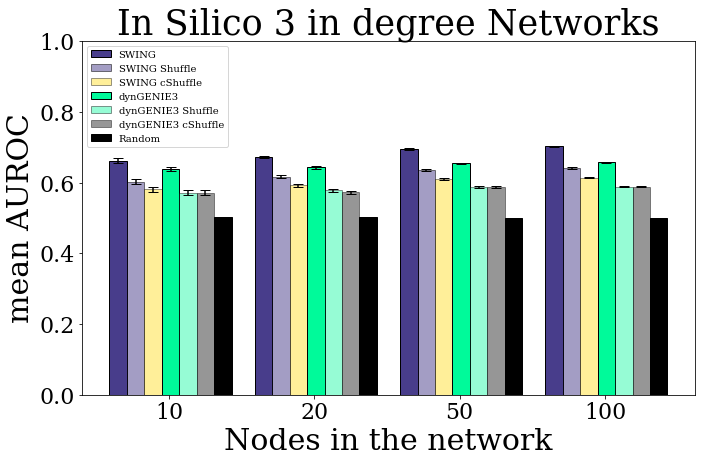

In [32]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)
plt.rcParams["font.family"] = "serif"

SWING = [mean(AUROC_value_SWING_list[f"AUROC_value_SWING_list_{nodes}genes"]) for nodes in Nodes]
SWING_std = [np.std(AUROC_value_SWING_list[f"AUROC_value_SWING_list_{nodes}genes"])/10 for nodes in Nodes]

SWING_rand = [mean(AUROC_value_SWING_list_rand[f"AUROC_value_SWING_list_{nodes}genes_rand"]) for nodes in Nodes]
SWING_rand_std = [np.std(AUROC_value_SWING_list_rand[f"AUROC_value_SWING_list_{nodes}genes_rand"])/10 for nodes in Nodes]

SWING_crand = [mean(AUROC_value_SWING_list_crand[f"AUROC_value_SWING_list_{nodes}genes_crand"]) for nodes in Nodes]
SWING_crand_std = [np.std(AUROC_value_SWING_list_crand[f"AUROC_value_SWING_list_{nodes}genes_crand"])/10 for nodes in Nodes]

dynGENIE3 = [mean(AUROC_value_dynGENIE3_list[f"AUROC_value_dynGENIE3_list_{nodes}genes"]) for nodes in Nodes]
dynGENIE3_std = [np.std(AUROC_value_dynGENIE3_list[f"AUROC_value_dynGENIE3_list_{nodes}genes"])/10 for nodes in Nodes]

dynGENIE3_rand = [mean(AUROC_value_dynGENIE3_list_rand[f"AUROC_value_dynGENIE3_list_{nodes}genes_rand"]) for nodes in Nodes]
dynGENIE3_rand_std = [np.std(AUROC_value_dynGENIE3_list_rand[f"AUROC_value_dynGENIE3_list_{nodes}genes_rand"])/10 for nodes in Nodes]

dynGENIE3_crand = [mean(AUROC_value_dynGENIE3_list_crand[f"AUROC_value_dynGENIE3_list_{nodes}genes_crand"]) for nodes in Nodes]
dynGENIE3_crand_std = [np.std(AUROC_value_dynGENIE3_list_crand[f"AUROC_value_dynGENIE3_list_{nodes}genes_crand"])/10 for nodes in Nodes]

random = [mean(AUROC_value_random_list[f"AUROC_value_random_list_{nodes}genes"]) for nodes in Nodes]
random_std = [np.std(AUROC_value_random_list[f"AUROC_value_random_list_{nodes}genes"])/10 for nodes in Nodes]

labels = ["10", "20", "50", "100"]
barWidth = 0.12

# Set position of bar on X axis
br1 = np.arange(len(SWING))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
br6 = [x + barWidth for x in br5]
br7 = [x + barWidth for x in br6]

plt.rc('xtick', labelsize=22)    
plt.rc('ytick', labelsize=22)    
plt.rcParams["font.family"] = "serif"
    
plt.figure(figsize=(11,6.5))

# Make the plot
plt.bar(br1, SWING, yerr=SWING_std,capsize=5, align='center', color='darkslateblue', width= barWidth, edgecolor= 'k', label='SWING')
plt.bar(br2, SWING_rand, yerr=SWING_rand_std,capsize=5, align='center', color='darkslateblue', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING Shuffle')
plt.bar(br3, SWING_crand, yerr=SWING_crand_std,capsize=5, align='center', color='#FFD700', alpha = 0.4, width= barWidth, edgecolor= 'k', label='SWING cShuffle')
plt.bar(br4, dynGENIE3, yerr=dynGENIE3_std,capsize=5, align='center', color='mediumspringgreen', alpha = 1,width= barWidth, edgecolor= 'k', label='dynGENIE3')
plt.bar(br5, dynGENIE3_rand, yerr=dynGENIE3_rand_std,capsize=5, align='center', color='mediumspringgreen', alpha = 0.41,width= barWidth, edgecolor= 'k', label='dynGENIE3 Shuffle')
plt.bar(br6, dynGENIE3_crand, yerr=dynGENIE3_crand_std,capsize=5, align='center', color='k', alpha = 0.41,width= barWidth, edgecolor= 'k', label='dynGENIE3 cShuffle')
plt.bar(br7, random, color='k', alpha = 1,width= barWidth, edgecolor= 'k', label='Random')

plt.ylabel('mean AUROC', family = 'serif',fontsize = 30)
plt.xlabel('Nodes in the network', family = 'serif',fontsize = 30)
#FFD700
plt.xticks([r + barWidth + 0.23 for r in range(len(SWING))], ["10", "20", "50", "100"])
plt.title("In Silico 3 in degree Networks", fontsize = 35)
plt.legend(prop={"size":10})
plt.ylim(0,1)
#plt.grid(linewidth=0.3)
#plt.savefig(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/Results/In_degree_Results/ROC_in_degree_2.png", bbox_inches="tight", dpi=100 )

# AUPRC

(0.0, 1.0)

<Figure size 576x360 with 0 Axes>

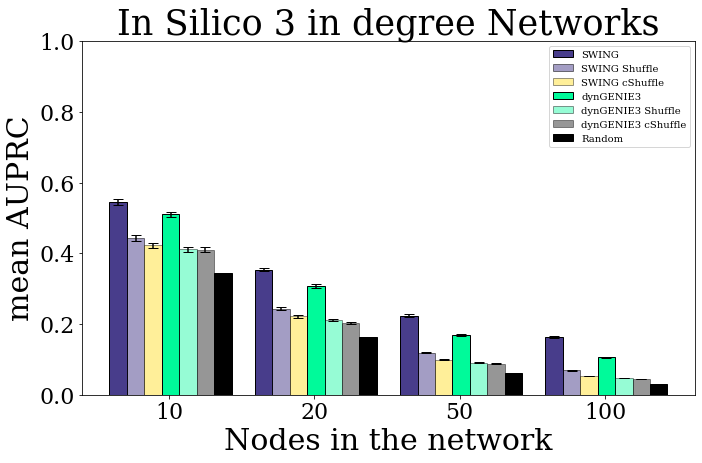

In [34]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)
plt.rcParams["font.family"] = "serif"

SWING = [mean(AUPRC_value_SWING_list[f"AUPRC_value_SWING_list_{nodes}genes"]) for nodes in Nodes]
SWING_std = [np.std(AUPRC_value_SWING_list[f"AUPRC_value_SWING_list_{nodes}genes"])/10 for nodes in Nodes]

SWING_rand = [mean(AUPRC_value_SWING_list_rand[f"AUPRC_value_SWING_list_{nodes}genes_rand"]) for nodes in Nodes]
SWING_rand_std = [np.std(AUPRC_value_SWING_list_rand[f"AUPRC_value_SWING_list_{nodes}genes_rand"])/10 for nodes in Nodes]

SWING_crand = [mean(AUPRC_value_SWING_list_crand[f"AUPRC_value_SWING_list_{nodes}genes_crand"]) for nodes in Nodes]
SWING_crand_std = [np.std(AUPRC_value_SWING_list_crand[f"AUPRC_value_SWING_list_{nodes}genes_crand"])/10 for nodes in Nodes]

dynGENIE3 = [mean(AUPRC_value_dynGENIE3_list[f"AUPRC_value_dynGENIE3_list_{nodes}genes"]) for nodes in Nodes]
dynGENIE3_std = [np.std(AUPRC_value_dynGENIE3_list[f"AUPRC_value_dynGENIE3_list_{nodes}genes"])/10 for nodes in Nodes]

dynGENIE3_rand = [mean(AUPRC_value_dynGENIE3_list_rand[f"AUPRC_value_dynGENIE3_list_{nodes}genes_rand"]) for nodes in Nodes]
dynGENIE3_rand_std = [np.std(AUPRC_value_dynGENIE3_list_rand[f"AUPRC_value_dynGENIE3_list_{nodes}genes_rand"])/10 for nodes in Nodes]

dynGENIE3_crand = [mean(AUPRC_value_dynGENIE3_list_crand[f"AUPRC_value_dynGENIE3_list_{nodes}genes_crand"]) for nodes in Nodes]
dynGENIE3_crand_std = [np.std(AUPRC_value_dynGENIE3_list_crand[f"AUPRC_value_dynGENIE3_list_{nodes}genes_crand"])/10 for nodes in Nodes]

random = [mean(AUPRC_value_random_list[f"AUPRC_value_random_list_{nodes}genes"]) for nodes in Nodes]
random_std = [np.std(AUPRC_value_random_list[f"AUPRC_value_random_list_{nodes}genes"])/10 for nodes in Nodes]

labels = ["10", "20", "50", "100"]
barWidth = 0.12

# Set position of bar on X axis
br1 = np.arange(len(SWING))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
br6 = [x + barWidth for x in br5]
br7 = [x + barWidth for x in br6]

plt.rc('xtick', labelsize=22)    
plt.rc('ytick', labelsize=22)    
plt.rcParams["font.family"] = "serif"
    
plt.figure(figsize=(11,6.5))

# Make the plot
plt.bar(br1, SWING, yerr=SWING_std,capsize=5, align='center', color='darkslateblue', width= barWidth, edgecolor= 'k', label='SWING')
plt.bar(br2, SWING_rand, yerr=SWING_rand_std,capsize=5, align='center', color='darkslateblue', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING Shuffle')
plt.bar(br3, SWING_crand, yerr=SWING_crand_std,capsize=5, align='center', color='#FFD700', alpha = 0.4, width= barWidth, edgecolor= 'k', label='SWING cShuffle')
plt.bar(br4, dynGENIE3, yerr=dynGENIE3_std,capsize=5, align='center', color='mediumspringgreen', alpha = 1,width= barWidth, edgecolor= 'k', label='dynGENIE3')
plt.bar(br5, dynGENIE3_rand, yerr=dynGENIE3_rand_std,capsize=5, align='center', color='mediumspringgreen', alpha = 0.41,width= barWidth, edgecolor= 'k', label='dynGENIE3 Shuffle')
plt.bar(br6, dynGENIE3_crand, yerr=dynGENIE3_crand_std,capsize=5, align='center', color='k', alpha = 0.41,width= barWidth, edgecolor= 'k', label='dynGENIE3 cShuffle')
plt.bar(br7, random, color='k', alpha = 1,width= barWidth, edgecolor= 'k', label='Random')

plt.ylabel('mean AUPRC', family = 'serif',fontsize = 30)
plt.xlabel('Nodes in the network', family = 'serif',fontsize = 30)
#FFD700
plt.xticks([r + barWidth + 0.23 for r in range(len(SWING))], ["10", "20", "50", "100"])
plt.title("In Silico 3 in degree Networks", fontsize = 35)
plt.legend(prop={"size":10})
plt.ylim(0,1)
#plt.grid(linewidth=0.3)
#plt.savefig(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/Results/In_degree_Results/ROC_in_degree_2.png", bbox_inches="tight", dpi=100 )